# Combining of the Views

This script performs inference using pre trained SNNs for each folds of each views. It generates predictions and logits for each fold and it saves the results. 


In [4]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import KFold
from model import SNN  
from data import BraTSVolumeDataset  
import os
import tarfile
from tqdm import tqdm
import argparse
random_state = 42
num_folds = 5
dataset_size = 110 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset_paths = {
    "axial": "data\slices_output\\axial2017.tar",
    "coronal": "data\slices_output\coronal2017.tar",
    "sagittal": "data\slices_output\sagittal2017.tar",
}

model_paths = {
    "axial": "results2017/results_axial_do_bce_0.01_np/models/fold_{}/model.pth",
    "coronal": "results2017/results_coronal_do_bce_0.01_np/models/fold_{}/model.pth",
    "sagittal": "results2017/results_sagittal_do_bce_0.01_np/models/fold_{}/model.pth",
}

frames_dict = {
    "axial": 152,
    "coronal": 192,
    "sagittal": 160,
}
subjects = set()
tar_file_path = "data\slices_output\\axial2017.tar"

with tarfile.open(tar_file_path, 'r') as tar:
    for member in tqdm(tar):
        parts = member.name.split('/')
        if len(parts) > 0:
            subjects.add(parts[0])
subjects = sorted(subjects)

kf = KFold(n_splits=num_folds, shuffle=True, random_state=random_state)
indices = list(range(len(subjects)))

for view in ["axial", "coronal", "sagittal"]:
    probabilities_dict = {f"fold_{i}": {} for i in range(num_folds)} 
    logits_dict = {f"fold_{i}": {} for i in range(num_folds)}
    for fold_idx, (train_indices, test_indices) in enumerate(kf.split(indices)):
        print(f"Processing Fold {fold_idx + 1}/{num_folds} for {view}...")
        
        dataset = BraTSVolumeDataset(
            tar_path=dataset_paths[view],
            subjects=subjects,
            n_slices=frames_dict[view],
            transform=None,
        )
        model_path = model_paths[view].format(fold_idx)
        print(f"  -> Loading model from {model_path}")
        model = SNN()  
        model.load_state_dict(torch.load(model_path, map_location=device), strict=False)
        model.to(device)

        for test_idx in tqdm(test_indices):
            image = dataset[test_idx][0].unsqueeze(0).to(device)  
            with torch.no_grad():

                logits = []
                total_slices = image.shape[2]
                for t in range(total_slices):
                    x_slice = image[:, :, t:t+1, :, :]
                    logit = model(x_slice)
                    logit = logit.squeeze(2)
                    logits.append(logit)
                logits = torch.stack(logits, dim=2)  # [B, C, T, H, W]
                probabilities = torch.softmax(logits, dim=1) 
            probabilities_dict[f"fold_{fold_idx}"][test_idx] = probabilities.cpu().numpy()
            logits_dict[f"fold_{fold_idx}"][test_idx] = logits.cpu().numpy()
    np.save(f"multi_view_results/multi_view_results_bce/predictions_{view}.npy", probabilities_dict)
    np.save(f"multi_view_results/multi_view_results_bce/logits_{view}.npy", logits_dict)
    print(f"Predictions for {view} saved successfully!")


152961it [00:12, 11886.79it/s]


Processing Fold 1/5 for axial...
  -> Loading model from results2017/results_axial_do_bce_0.01_np/models/fold_0/model.pth


 37%|███▋      | 15/41 [08:15<14:19, 33.05s/it]


KeyboardInterrupt: 

# Combining the Predictions of the different views

Each instance of each fold has 3 outputs (1 for each view). 
The logits are aggregated. 
You then compute the standard deviation. 

In [38]:
import numpy as np
import os
import torch

prediction_dir = "multi_view_results_bce"
os.makedirs(prediction_dir, exist_ok=True) 

views = ["axial", "sagittal", "coronal"]
prediction_files = {view: os.path.join(prediction_dir, f"logits_{view}.npy") for view in views}

predictions = {view: np.load(prediction_files[view], allow_pickle=True).item() for view in views}

num_folds = 5  
aligned_predictions = {f"fold_{i}": {} for i in range(num_folds)}

for fold in range(num_folds):
    print(f"Processing Fold {fold}...")

    pred1_tensor = {k: torch.tensor(v) for k, v in predictions["sagittal"][f"fold_{fold}"].items()}
    pred2_tensor = {k: torch.tensor(v) for k, v in predictions["view2"][f"fold_{fold}"].items()}
    pred3_tensor = {k: torch.tensor(v) for k, v in predictions["view3"][f"fold_{fold}"].items()}
    fold_dir = os.path.join(prediction_dir, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    for key in pred1_tensor.keys():
        pred1 = pred1_tensor[key]
        pred2 = pred2_tensor[key]
        pred3 = pred3_tensor[key]
        pred3 = pred3.permute(0, 1, 4, 3, 2)
        pred1 = pred1.permute(0, 1, 4, 2, 3).permute(0, 1, 3, 4, 2).flip(3).permute(0, 1, 3, 2, 4).flip(2)

        prob1 = torch.softmax(pred1, dim=1)
        prob2 = torch.softmax(pred2, dim=1)
        prob3 = torch.softmax(pred3, dim=1)

        combined_preds = torch.stack([pred1, pred2, pred3], dim=0)
        combined_probs = torch.stack([prob1, prob2, prob3], dim=0)  
        mean_logits = torch.mean(combined_preds, dim=0)   #combine with the mean
        mean_probs = torch.mean(combined_probs, dim=0)  #combine with the mean  
        std_preds = torch.std(combined_preds, dim=0)  # Shape: (N, C) or (C, H, W)
        predicted_labels = torch.argmax(mean_logits, dim=1, keepdim=True)  # Shape: (N, 1) 

        uncertainty_channel = std_preds[:, 1, ...].unsqueeze(1)  # Shape: (N, 1, ...)

        predicted_labels_with_uncertainty = torch.cat((predicted_labels, uncertainty_channel), dim=1)  
        # Final shape: (N, 2, ...), where:
        # - Channel 0: Predicted labels
        # - Channel 1: Uncertainty (std deviation of class 1)

        torch.save(mean_logits, os.path.join(fold_dir, f"{key}_mean_logits.pt"))

        torch.save(predicted_labels_with_uncertainty, os.path.join(fold_dir, f"{key}_predicted_labels.pt"))
        torch.save(std_preds, os.path.join(fold_dir, f"{key}_std_preds.pt"))
        torch.save(mean_probs, os.path.join(fold_dir, f"{key}_mean_probs.pt"))
        print(f"Saved tensors for {key} in {fold_dir}")

print("Processing complete. Predictions saved successfully!")


FileNotFoundError: [Errno 2] No such file or directory: 'multi_view_results_bce\\logits_coronal.npy'

# LOGITS AGGREGATION


In [ ]:
from statistics import mean
from tqdm import tqdm

import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.utils.data import Dataset
from torch.nn.functional import cross_entropy, softmax

from torchmetrics.classification import Dice
from torch.utils.data import DataLoader
from model import SNN
from data import HippoDataset

import json
import os
import pandas as pd

available_device = (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("mps")
)

4


def get_confusion_matrix(target, prediction):
    labels = np.unique(target)
    confusion_mat = confusion_matrix(
        target.flatten(), prediction.flatten(), labels=labels
    )
    return confusion_mat


def dice_ratio(target, prediction):
    confusion_mat = get_confusion_matrix(target, prediction)
    true_positives = np.float64(confusion_mat.diagonal())
    class_actual_sums = np.sum(confusion_mat, axis=1)
    false_negative = class_actual_sums - true_positives
    class_predicted_sums = np.sum(confusion_mat, axis=0)
    false_positive = class_predicted_sums - true_positives
    dice_ratio = (2 * true_positives) / (
        2 * true_positives + false_negative + false_positive
    )
    return dice_ratio

# Path to saved predictions and models
prediction_dir = "multi_view_results/multi_view_results_bce"
model_dir = "results/results2_bce/models"
data_path = "./data/data2"

num_folds = 5
batch_size = 1
frames = 56

dataset = HippoDataset(data_path, range(1, 111), frames)
indices = list(range(len(dataset)))
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

performance_results = {}
dice_metric = Dice(num_classes=2, ignore_index=0)

for fold, (_, test_idx) in enumerate(kf.split(indices)):
    print(f"Evaluating Fold {fold}...")
    fold_dir = os.path.join(prediction_dir, f"fold_{fold}")
    model_fold_dir = os.path.join(model_dir, f"fold_{fold}")

    test_subset = torch.utils.data.Subset(dataset, test_idx)
    test_loader = DataLoader(test_subset, batch_size=batch_size, num_workers=4, shuffle=False)


    dice_scores = []
    brier_scores = []
    nll_scores = []
    avg_briers = []
    avg_nlls = []
    confidences = []
    avg_confidences = []
    results_dict = {
        "image_index": [],
        "dice": [],
        'sd_dice': [],
        "brier": [],
        "avg_brier": [],
        "sd_brier": [],
        "nll": [],
        "avg_nll": [],
        "sd_nll": [],
        "avg_confidence": [],
        "sd_confidence": []
         
    }

    with torch.no_grad():
        for image_index, (x, y) in tqdm(enumerate(test_loader), total=len(test_loader), desc=f"Evaluating Fold {fold}"):
            # Load saved mean_preds (logits)
            mean_preds = torch.load(os.path.join(fold_dir, f"{test_idx[image_index]}_mean_logits.pt"))
            mean_preds = torch.softmax(mean_preds, dim=1)
            pred_class = torch.argmax(mean_preds, dim=1)
            # Compute DICE score
            dice_value = dice_metric(pred_class, y).item()
            dice_scores.append(dice_value)
            # Compute Brier Score
            y_one_hot = torch.zeros_like(mean_preds).scatter_(1, y.unsqueeze(1), 1)
            y_one_hot = y_one_hot.permute(0, 2, 3, 4, 1)
            probs_brier = mean_preds.permute(0, 2, 3, 4, 1)
            brier_score_sample = torch.mean((probs_brier - y_one_hot) ** 2, dim=(2, 3, 4)).tolist()
            brier_scores.extend(brier_score_sample)
            # Compute NLL
            true_probs = mean_preds.gather(1, y.unsqueeze(1)).squeeze(1)
            nll = -torch.log(true_probs + 1e-9)
            batch_nll = nll.mean(dim=(2, 3)).tolist()
            nll_scores.extend(batch_nll)
            # Compute Confidence (the probability of the predicted class)
            pred_probs, pred_classes = torch.max(probabilities, dim=1) 
            avg_confidence_sample = pred_probs.mean(dim=(1, 2)).tolist() 
            confidences.extend(avg_confidence_sample)

            for i in range(len(batch_nll)):
                results_dict["image_index"].append(image_index)
                results_dict["dice"].append(dice_value)
                results_dict["sd_dice"].append(np.std(dice_scores))
                results_dict["brier"].append(brier_score_sample[i])
                results_dict["avg_brier"].append(mean(brier_score_sample[i]))
                results_dict["sd_brier"].append(np.std(brier_score_sample[i]))
                results_dict["nll"].append(batch_nll[i])
                results_dict["avg_nll"].append(mean(batch_nll[i]))
                results_dict["sd_nll"].append(np.std(batch_nll[i]))
                results_dict["avg_confidence"].append(mean(avg_confidence_sample[i]))
                results_dict["sd_confidence"].append(np.std(avg_confidence_sample[i]))
                avg_briers.append(mean(brier_score_sample[i]))
                avg_nlls.append(mean(batch_nll[i]))
                avg_confidences.append(mean(avg_confidence_sample[i]))

            tqdm.write(f"Image {image_index}: DICE {dice_value}, Brier {mean(brier_score_sample[i]):.4f}, NLL {mean(batch_nll[i]):.4f}, Confidence {mean(avg_confidence_sample[i]):.4f}")

    performance_results[f"fold_{fold}"] = {
        "DICE": np.mean(dice_scores),
        "Brier": np.mean(avg_briers),
        "NLL": np.mean(avg_nlls),
        "Confidence": np.mean(avg_confidences)
    }

    results_df = pd.DataFrame(results_dict)
    results_df.to_csv(os.path.join(fold_dir, f"performance_results_fold_{fold}.csv"), index=False)


Evaluating Fold 0...


Evaluating Fold 0:   0%|          | 0/22 [00:00<?, ?it/s]C:\Users\Aurora Pia Ghiardell\AppData\Local\Temp\ipykernel_35008\2047707205.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experiment

Image 0: DICE 0.9076376557350159, Brier 0.0035, NLL 0.0113, Confidence 0.9948
Image 1: DICE 0.8564383387565613, Brier 0.0061, NLL 0.0211, Confidence 0.9948
Image 2: DICE 0.875977635383606, Brier 0.0064, NLL 0.0220, Confidence 0.9948
Image 3: DICE 0.7567567825317383, Brier 0.0059, NLL 0.0227, Confidence 0.9948
Image 4: DICE 0.5721649527549744, Brier 0.0153, NLL 0.0803, Confidence 0.9948
Image 5: DICE 0.5151898860931396, Brier 0.0208, NLL 0.1329, Confidence 0.9948
Image 6: DICE 0.8565287590026855, Brier 0.0031, NLL 0.0103, Confidence 0.9948
Image 7: DICE 0.6920635104179382, Brier 0.0106, NLL 0.0466, Confidence 0.9948
Image 8: DICE 0.865128219127655, Brier 0.0062, NLL 0.0210, Confidence 0.9948
Image 9: DICE 0.7323362827301025, Brier 0.0062, NLL 0.0241, Confidence 0.9948


Evaluating Fold 0:  91%|█████████ | 20/22 [00:06<00:00,  6.12it/s]

Image 10: DICE 0.8141762614250183, Brier 0.0046, NLL 0.0175, Confidence 0.9948
Image 11: DICE 0.8205912113189697, Brier 0.0084, NLL 0.0351, Confidence 0.9948
Image 12: DICE 0.8157286047935486, Brier 0.0087, NLL 0.0336, Confidence 0.9948
Image 13: DICE 0.843137264251709, Brier 0.0049, NLL 0.0173, Confidence 0.9948
Image 14: DICE 0.865376353263855, Brier 0.0034, NLL 0.0117, Confidence 0.9948
Image 15: DICE 0.8351770043373108, Brier 0.0035, NLL 0.0121, Confidence 0.9948
Image 16: DICE 0.8745214939117432, Brier 0.0034, NLL 0.0115, Confidence 0.9948
Image 17: DICE 0.8532189130783081, Brier 0.0059, NLL 0.0200, Confidence 0.9948
Image 18: DICE 0.8757807016372681, Brier 0.0039, NLL 0.0125, Confidence 0.9948
Image 19: DICE 0.7218435406684875, Brier 0.0105, NLL 0.0422, Confidence 0.9948
Image 20: DICE 0.8303614258766174, Brier 0.0087, NLL 0.0400, Confidence 0.9948
Image 21: DICE 0.717391312122345, Brier 0.0059, NLL 0.0218, Confidence 0.9948


...

Evaluating Fold 4:  32%|███▏      | 7/22 [00:04<00:07,  2.07it/s]

Image 0: DICE 0.8848263025283813, Brier 0.0043, NLL 0.0147, Confidence 0.9948
Image 1: DICE 0.7876489758491516, Brier 0.0046, NLL 0.0161, Confidence 0.9948
Image 2: DICE 0.7881481647491455, Brier 0.0050, NLL 0.0187, Confidence 0.9948
Image 3: DICE 0.7662517428398132, Brier 0.0039, NLL 0.0137, Confidence 0.9948
Image 4: DICE 0.8403687477111816, Brier 0.0037, NLL 0.0122, Confidence 0.9948
Image 5: DICE 0.76346355676651, Brier 0.0110, NLL 0.0486, Confidence 0.9948
Image 6: DICE 0.8348405361175537, Brier 0.0040, NLL 0.0132, Confidence 0.9948
Image 7: DICE 0.8211855888366699, Brier 0.0041, NLL 0.0138, Confidence 0.9948
Image 8: DICE 0.8733078837394714, Brier 0.0043, NLL 0.0154, Confidence 0.9948


Evaluating Fold 4:  91%|█████████ | 20/22 [00:04<00:00,  8.36it/s]

Image 9: DICE 0.8276249170303345, Brier 0.0037, NLL 0.0123, Confidence 0.9948
Image 10: DICE 0.8350397944450378, Brier 0.0069, NLL 0.0256, Confidence 0.9948
Image 11: DICE 0.829748272895813, Brier 0.0091, NLL 0.0426, Confidence 0.9948
Image 12: DICE 0.648169994354248, Brier 0.0153, NLL 0.0725, Confidence 0.9948
Image 13: DICE 0.6980010867118835, Brier 0.0069, NLL 0.0281, Confidence 0.9948
Image 14: DICE 0.8588695526123047, Brier 0.0047, NLL 0.0160, Confidence 0.9948
Image 15: DICE 0.81533282995224, Brier 0.0088, NLL 0.0320, Confidence 0.9948
Image 16: DICE 0.856213390827179, Brier 0.0077, NLL 0.0272, Confidence 0.9948
Image 17: DICE 0.8190423250198364, Brier 0.0075, NLL 0.0289, Confidence 0.9948
Image 18: DICE 0.8390636444091797, Brier 0.0051, NLL 0.0186, Confidence 0.9948
Image 19: DICE 0.8026628494262695, Brier 0.0049, NLL 0.0178, Confidence 0.9948
Image 20: DICE 0.7768736481666565, Brier 0.0063, NLL 0.0233, Confidence 0.9948
Image 21: DICE 0.8542936444282532, Brier 0.0060, NLL 0.021

Evaluating Fold 4: 100%|██████████| 22/22 [00:05<00:00,  3.97it/s]


You aggregate the evaluation metrics for each fold.
 

In [ ]:
import os
import pandas as pd
import numpy as np

prediction_dir = "multi_view_results_bce"
num_folds = 5

mean_metrics = ["dice", "avg_brier", "avg_nll", "avg_confidence"]
std_metrics = ['sd_dice', "sd_brier", "sd_nll", "sd_confidence"]

fold_means = {metric: [] for metric in mean_metrics}
fold_stds = {metric: [] for metric in std_metrics}

for fold in range(num_folds):
    fold_file = os.path.join(prediction_dir, f"fold_{fold}", f"performance_results_fold_{fold}.csv")
    if os.path.exists(fold_file):
        df = pd.read_csv(fold_file)
        
        for metric in mean_metrics:
            if metric in df.columns:
                fold_means[metric].append(df[metric].mean())  # Compute mean for the fold
        
        for metric in std_metrics:
            if metric in df.columns:
                fold_stds[metric].append(df[metric].mean())  # Compute mean of std deviations in the fold

overall_means = {metric: np.mean(fold_means[metric]) for metric in mean_metrics if fold_means[metric]}

# Compute the overall standard deviation using the formula:
# Final SD = mean(SD of folds) + SD(mean values across folds)
overall_stds = {}
for metric in std_metrics:
    if fold_stds[metric]:  # Ensure we have values
        mean_std_across_folds = np.mean(fold_stds[metric])  # Mean of std deviations per fold
        std_of_means = np.std(fold_stds[metric]) if metric.replace("sd_", "avg_") in mean_metrics else 0  # SD of means across folds
        overall_stds[metric] = mean_std_across_folds + std_of_means

print("Mean values per fold:")
for metric in mean_metrics:
    print(f"{metric}: {fold_means[metric]}")

print("\nStandard deviations per fold:")
for metric in std_metrics:
    print(f"{metric}: {fold_stds[metric]}")

print("\nOverall mean across all folds:")
for metric, mean_value in overall_means.items():
    print(f"{metric}: {mean_value:.4f}")

print("\nOverall standard deviations across all folds:")
for metric, std_value in overall_stds.items():
    print(f"{metric}: {std_value:.4f}")



Mean values per fold:
dice: [0.7953420958735726, 0.7637966911901127, 0.8048154657537286, 0.8066131851889871, 0.8100444295189597]
avg_brier: [0.007086545295325491, 0.007853548406661174, 0.006888715543881674, 0.007244907225571113, 0.006273089786214656]
avg_nll: [0.030338129476193153, 0.033396723811393095, 0.03102172047898349, 0.03617460559530427, 0.024204722867665472]
avg_confidence: [0.9948207310267854, 0.9948207310267854, 0.9948207310267854, 0.9948207310267854, 0.9948207310267854]

Standard deviations per fold:
sd_dice: [0.10123450828558869, 0.18316951377159743, 0.06034335347769379, 0.07210049922642704, 0.0476362962535698]
sd_brier: [0.0070584777934970646, 0.007583022690961638, 0.006830250358567399, 0.006928101708616908, 0.00609413308561273]
sd_nll: [0.032635088279974474, 0.03341267838891989, 0.03440964845741907, 0.038983585688175705, 0.025190413922689045]
sd_confidence: [0.004772155831717, 0.004772155831717, 0.004772155831717, 0.004772155831717, 0.004772155831717]

Overall mean across

: 

: 

# PROBABILITIES AGGREGATION

In [ ]:
from statistics import mean
from tqdm import tqdm

import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.utils.data import Dataset
from torch.nn.functional import cross_entropy, softmax

from torchmetrics.classification import Dice
from torch.utils.data import DataLoader
from model import SNN
from data import HippoDataset

import json
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import KFold
from model import SNN  
from data import BraTSVolumeDataset  
import os
import tarfile
from tqdm import tqdm
import argparse
random_state = 42
num_folds = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


available_device = (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("mps")
)




# Path to saved predictions and models
prediction_dir = "multi_view_results_bce"
model_dir = "results/results2_bce/models"
data_path = "./data/data2"

num_folds = 5
batch_size = 1
frames = 152

subjects = set()
tar_file_path = "data\slices_output\\axial2017.tar"
with tarfile.open(tar_file_path, 'r') as tar:
    for member in tqdm(tar):
        parts = member.name.split('/')
        if len(parts) > 0:
            subjects.add(parts[0])
subjects = sorted(subjects)

dataset = BraTSVolumeDataset(
    tar_path=dataset_paths[view],
    subjects=subjects,
    n_slices=frames_dict[view],
    transform=None,
)

indices = list(range(len(dataset)))
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

performance_results = {}
dice_metric = Dice(num_classes=2, ignore_index=0)

for fold, (_, test_idx) in enumerate(kf.split(indices)):
    print(f"Evaluating Fold {fold}...")
    fold_dir = os.path.join(prediction_dir, f"fold_{fold}")
    model_fold_dir = os.path.join(model_dir, f"fold_{fold}")

    test_subset = torch.utils.data.Subset(dataset, test_idx)
    test_loader = DataLoader(test_subset, batch_size=batch_size, num_workers=4, shuffle=False)
    dice_scores = []
    brier_scores = []
    nll_scores = []
    avg_briers = []
    avg_nlls = []
    confidences = []
    avg_confidences = []
    results_dict = {
        "image_index": [],
        "dice": [],
        'sd_dice': [],
        "brier": [],
        "avg_brier": [],
        "sd_brier": [],
        "nll": [],
        "avg_nll": [],
        "sd_nll": [],
        "avg_confidence": [],
        "sd_confidence": []
         
    }

    with torch.no_grad():
        for image_index, (x, y) in tqdm(enumerate(test_loader), total=len(test_loader), desc=f"Evaluating Fold {fold}"):
            # Load saved mean_preds (logits)
            mean_preds = torch.load(os.path.join(fold_dir, f"{test_idx[image_index]}_mean_probs.pt"))
            pred_class = torch.argmax(mean_preds, dim=1)
            # Compute DICE score
            dice_value = dice_metric(pred_class, y).item()
            dice_scores.append(dice_value)
            # Compute Brier Score
            y_one_hot = torch.zeros_like(mean_preds).scatter_(1, y.unsqueeze(1), 1)
            y_one_hot = y_one_hot.permute(0, 2, 3, 4, 1)
            probs_brier = mean_preds.permute(0, 2, 3, 4, 1)
            brier_score_sample = torch.mean((probs_brier - y_one_hot) ** 2, dim=(2, 3, 4)).tolist()
            brier_scores.extend(brier_score_sample)
            # Compute NLL
            true_probs = mean_preds.gather(1, y.unsqueeze(1)).squeeze(1)
            nll = -torch.log(true_probs + 1e-9)
            batch_nll = nll.mean(dim=(2, 3)).tolist()
            nll_scores.extend(batch_nll)
            # Compute Confidence (the probability of the predicted class)
            pred_probs, pred_classes = torch.max(probabilities, dim=1) 
            avg_confidence_sample = pred_probs.mean(dim=(1, 2)).tolist() 
            confidences.extend(avg_confidence_sample)

            for i in range(len(batch_nll)):
                results_dict["image_index"].append(image_index)
                results_dict["dice"].append(dice_value)
                results_dict["sd_dice"].append(np.std(dice_scores))
                results_dict["brier"].append(brier_score_sample[i])
                results_dict["avg_brier"].append(mean(brier_score_sample[i]))
                results_dict["sd_brier"].append(np.std(brier_score_sample[i]))
                results_dict["nll"].append(batch_nll[i])
                results_dict["avg_nll"].append(mean(batch_nll[i]))
                results_dict["sd_nll"].append(np.std(batch_nll[i]))
                results_dict["avg_confidence"].append(mean(avg_confidence_sample[i]))
                results_dict["sd_confidence"].append(np.std(avg_confidence_sample[i]))
                avg_briers.append(mean(brier_score_sample[i]))
                avg_nlls.append(mean(batch_nll[i]))
                avg_confidences.append(mean(avg_confidence_sample[i]))

            tqdm.write(f"Image {image_index}: DICE {dice_value}, Brier {mean(brier_score_sample[i]):.4f}, NLL {mean(batch_nll[i]):.4f}, Confidence {mean(avg_confidence_sample[i]):.4f}")

    performance_results[f"fold_{fold}"] = {
        "DICE": np.mean(dice_scores),
        "Brier": np.mean(avg_briers),
        "NLL": np.mean(avg_nlls),
        "Confidence": np.mean(avg_confidences)
    }

    results_df = pd.DataFrame(results_dict)
    results_df.to_csv(os.path.join(fold_dir, f"performance_results_fold_{fold}_probs.csv"), index=False)


Evaluating Fold 0...


Evaluating Fold 0:   0%|          | 0/22 [00:00<?, ?it/s]

C:\Users\Aurora Pia Ghiardell\AppData\Local\Temp\ipykernel_35008\2889828852.py:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean_preds = torch.load(os.path.join(fold_d

Image 0: DICE 0.9001490473747253, Brier 0.0039, NLL 0.0131, Confidence 0.9948
Image 1: DICE 0.8594726920127869, Brier 0.0060, NLL 0.0203, Confidence 0.9948
Image 2: DICE 0.8699752688407898, Brier 0.0067, NLL 0.0222, Confidence 0.9948
Image 3: DICE 0.7538233995437622, Brier 0.0058, NLL 0.0202, Confidence 0.9948
Image 4: DICE 0.5090628862380981, Brier 0.0138, NLL 0.0535, Confidence 0.9948
Image 5: DICE 0.5323076844215393, Brier 0.0172, NLL 0.0658, Confidence 0.9948
Image 6: DICE 0.8683651685714722, Brier 0.0032, NLL 0.0107, Confidence 0.9948
Image 7: DICE 0.6904593706130981, Brier 0.0094, NLL 0.0330, Confidence 0.9948
Image 8: DICE 0.8633460998535156, Brier 0.0060, NLL 0.0196, Confidence 0.9948


Evaluating Fold 0:  73%|███████▎  | 16/22 [00:06<00:01,  4.89it/s]

...

Evaluating Fold 4:  86%|████████▋ | 19/22 [00:04<00:00,  7.92it/s]

Image 10: DICE 0.8518105745315552, Brier 0.0062, NLL 0.0205, Confidence 0.9948
Image 11: DICE 0.834168553352356, Brier 0.0084, NLL 0.0296, Confidence 0.9948
Image 12: DICE 0.6786222457885742, Brier 0.0126, NLL 0.0429, Confidence 0.9948
Image 13: DICE 0.7798488736152649, Brier 0.0051, NLL 0.0165, Confidence 0.9948
Image 14: DICE 0.8616796135902405, Brier 0.0046, NLL 0.0154, Confidence 0.9948
Image 15: DICE 0.8249486684799194, Brier 0.0075, NLL 0.0239, Confidence 0.9948
Image 16: DICE 0.8745198249816895, Brier 0.0067, NLL 0.0215, Confidence 0.9948
Image 17: DICE 0.8397819995880127, Brier 0.0067, NLL 0.0223, Confidence 0.9948
Image 18: DICE 0.8484408855438232, Brier 0.0050, NLL 0.0170, Confidence 0.9948
Image 19: DICE 0.7954111099243164, Brier 0.0047, NLL 0.0167, Confidence 0.9948
Image 20: DICE 0.778723418712616, Brier 0.0059, NLL 0.0205, Confidence 0.9948


Evaluating Fold 4:  86%|████████▋ | 19/22 [00:04<00:00,  7.92it/s]

Image 21: DICE 0.8650575876235962, Brier 0.0057, NLL 0.0191, Confidence 0.9948


Evaluating Fold 4: 100%|██████████| 22/22 [00:05<00:00,  4.05it/s]


In [45]:
import os
import pandas as pd
import numpy as np

prediction_dir = "multi_view_results_cl_2"
num_folds = 5

mean_metrics = ["dice", "avg_brier", "avg_nll", "avg_confidence"]
std_metrics = ['sd_dice', "sd_brier", "sd_nll", "sd_confidence"]

fold_means = {metric: [] for metric in mean_metrics}
fold_stds = {metric: [] for metric in std_metrics}

for fold in range(num_folds):
    fold_file = os.path.join(prediction_dir, f"performance_results_fold_{fold}_probs.csv")
    if os.path.exists(fold_file):
        df = pd.read_csv(fold_file)
        
        for metric in mean_metrics:
            if metric in df.columns:
                fold_means[metric].append(df[metric].mean())  # Compute mean for the fold
        
        for metric in std_metrics:
            if metric in df.columns:
                fold_stds[metric].append(df[metric].mean())  # Compute mean of std deviations in the fold

overall_means = {metric: np.mean(fold_means[metric]) for metric in mean_metrics if fold_means[metric]}

# Compute the overall standard deviation using the formula:
# Final SD = mean(SD of folds) + SD(mean values across folds)
overall_stds = {}
for metric in std_metrics:
    if fold_stds[metric]:  # Ensure we have values
        mean_std_across_folds = np.mean(fold_stds[metric])  # Mean of std deviations per fold
        std_of_means = np.std(fold_stds[metric]) if metric.replace("sd_", "avg_") in mean_metrics else 0  # SD of means across folds
        overall_stds[metric] = mean_std_across_folds + std_of_means

print("Mean values per fold:")
for metric in mean_metrics:
    print(f"{metric}: {fold_means[metric]}")

print("\nStandard deviations per fold:")
for metric in std_metrics:
    print(f"{metric}: {fold_stds[metric]}")

print("\nOverall mean across all folds:")
for metric, mean_value in overall_means.items():
    print(f"{metric}: {mean_value:.4f}")

print("\nOverall standard deviations across all folds:")
for metric, std_value in overall_stds.items():
    print(f"{metric}: {std_value:.4f}")
    # Save the overall mean and standard deviations across all folds to a CSV file
summary_data = {**overall_means, **overall_stds}
summary_df = pd.DataFrame([summary_data])
summary_file_path = os.path.join(prediction_dir, "overall_summary.csv")
summary_df.to_csv(summary_file_path, index=False)

print(f"\nOverall summary saved to {summary_file_path}")




Mean values per fold:
dice: [np.float64(0.7661467357515155), np.float64(0.7498586940244418), np.float64(0.8161667289458144), np.float64(0.8127237675365702), np.float64(0.8061452395743254)]
avg_brier: [np.float64(0.002894919290575249), np.float64(0.0029258488544197077), np.float64(0.00305521533343152), np.float64(0.0027206896686810373), np.float64(0.003184185793428298)]
avg_nll: [np.float64(0.039733553097521926), np.float64(0.04847328696563854), np.float64(0.04032554185101339), np.float64(0.0340777529566393), np.float64(0.05154770712486108)]
avg_confidence: []

Standard deviations per fold:
sd_dice: [np.float64(0.09963677289498798), np.float64(0.16614328198322986), np.float64(0.08806146798738668), np.float64(0.08459967592838342), np.float64(0.1364442836587717)]
sd_brier: [np.float64(0.003861116041271249), np.float64(0.0038080492787824676), np.float64(0.003983322717312462), np.float64(0.0034254993245322247), np.float64(0.004264987899391811)]
sd_nll: [np.float64(0.05594336996144878), np.f

In [ ]:
import os
import pandas as pd
import numpy as np

prediction_dir = "multi_view_results_cl_2"
num_folds = 5

mean_metrics = ["dice", "avg_brier", "avg_nll", "avg_confidence"]
std_metrics = ['sd_dice', "sd_brier", "sd_nll", "sd_confidence"]

fold_means = {metric: [] for metric in mean_metrics}
fold_stds = {metric: [] for metric in std_metrics}

fold_data = {}  # Dictionary to store per-fold datasets

for fold in range(num_folds):
    fold_file = os.path.join(prediction_dir, f"performance_results_fold_{fold}_probs.csv")
    if os.path.exists(fold_file):
        df = pd.read_csv(fold_file)
        fold_dataset = {}
        
        for metric in mean_metrics:
            if metric in df.columns:
                mean_value = df[metric].mean()
                fold_means[metric].append(mean_value)
                fold_dataset[metric] = mean_value
        
        for metric in std_metrics:
            if metric in df.columns:
                std_value = df[metric].mean()
                fold_stds[metric].append(std_value)
                fold_dataset[metric] = std_value
        
        fold_df = pd.DataFrame([fold_dataset])  # Convert dict to DataFrame
        fold_data[f"fold_{fold}"] = fold_df
        fold_df.to_csv(os.path.join(prediction_dir, f"fold_{fold}_summary.csv"), index=False)
        print("\n")
        print(f"Saved dataset for Fold {fold}")
        print(fold_df)
overall_means = {metric: np.mean(fold_means[metric]) for metric in mean_metrics if fold_means[metric]}
overall_stds = {}
for metric in std_metrics:
    if fold_stds[metric]:
        mean_std_across_folds = np.mean(fold_stds[metric])
        std_of_means = np.std(fold_stds[metric]) if metric.replace("sd_", "avg_") in mean_metrics else 0
        overall_stds[metric] = mean_std_across_folds + std_of_means

summary_data = {**overall_means, **overall_stds}
summary_df = pd.DataFrame([summary_data])
summary_df.to_csv(os.path.join(prediction_dir, "overall_summary.csv"), index=False)
print("\nOverall mean across all folds:")
for metric, mean_value in overall_means.items():
    print(f"{metric}: {mean_value:.4f}")

print("\nOverall standard deviations across all folds:")
for metric, std_value in overall_stds.items():
    print(f"{metric}: {std_value:.4f}")



Saved dataset for Fold 0
       dice  avg_brier   avg_nll   sd_dice  sd_brier    sd_nll
0  0.766147   0.002895  0.039734  0.099637  0.003861  0.055943


Saved dataset for Fold 1
       dice  avg_brier   avg_nll   sd_dice  sd_brier    sd_nll
0  0.749859   0.002926  0.048473  0.166143  0.003808  0.067337


Saved dataset for Fold 2
       dice  avg_brier   avg_nll   sd_dice  sd_brier    sd_nll
0  0.816167   0.003055  0.040326  0.088061  0.003983  0.055387


Saved dataset for Fold 3
       dice  avg_brier   avg_nll  sd_dice  sd_brier    sd_nll
0  0.812724   0.002721  0.034078   0.0846  0.003425  0.046225


Saved dataset for Fold 4
       dice  avg_brier   avg_nll   sd_dice  sd_brier    sd_nll
0  0.806145   0.003184  0.051548  0.136444  0.004265  0.073303

Overall mean across all folds:
dice: 0.7902
avg_brier: 0.0030
avg_nll: 0.0428

Overall standard deviations across all folds:
sd_dice: 0.1150
sd_brier: 0.0041
sd_nll: 0.0692


# Visualization


152961it [00:13, 11342.41it/s]


Image shape: (152, 160, 192)
Label shape: (152, 160, 192)


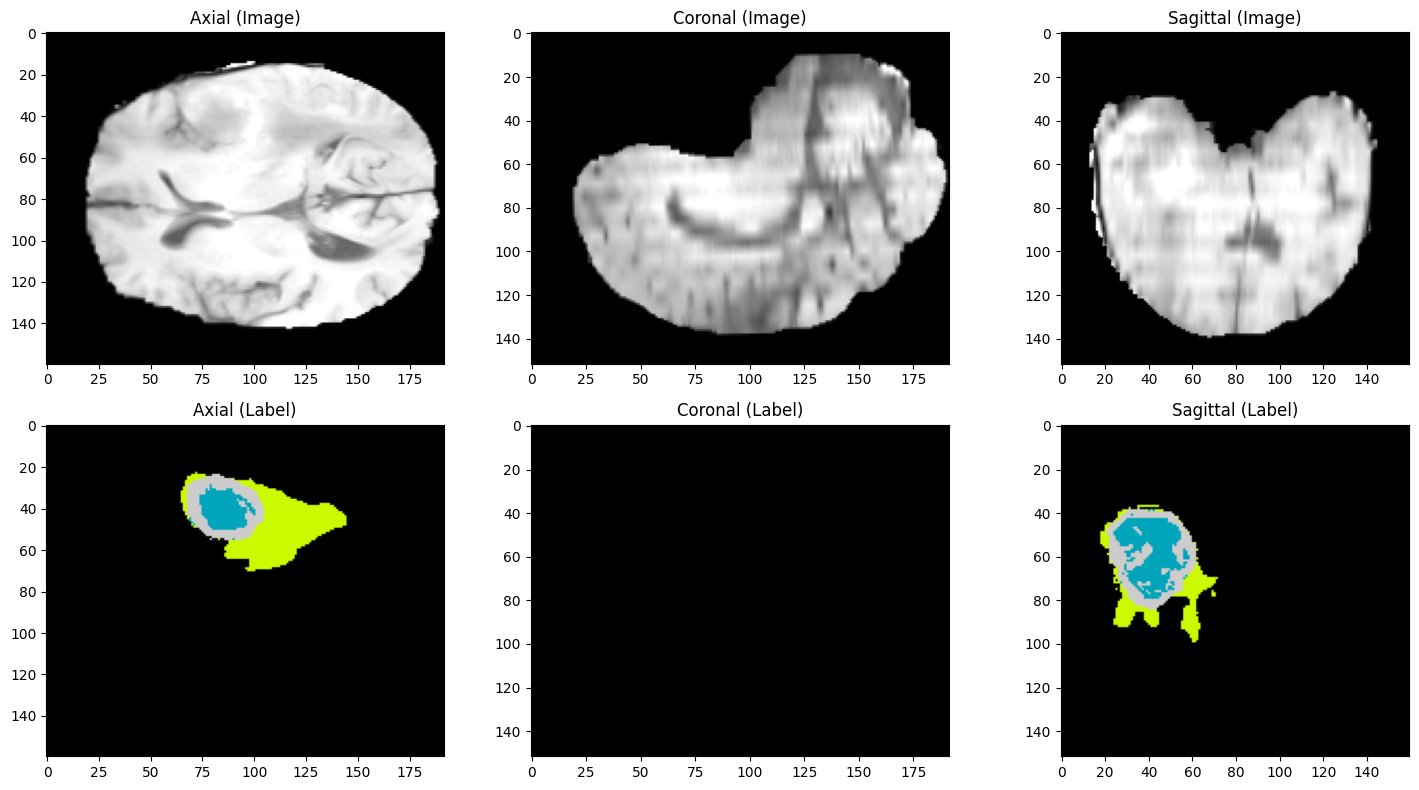


Use your mouse wheel to scroll through the axial slices...


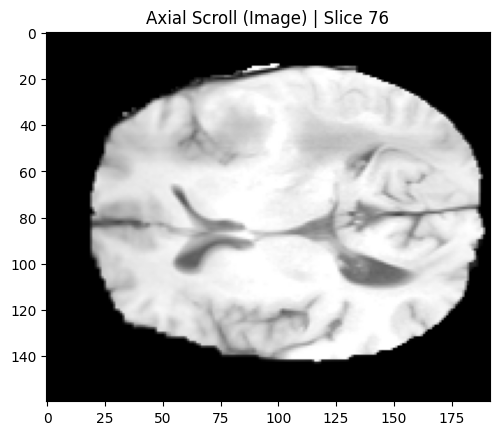

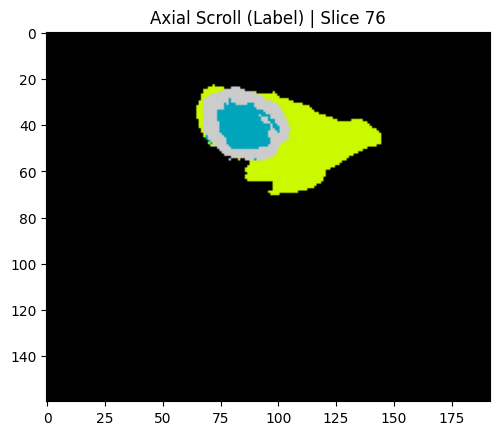

In [37]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import KFold
from model import SNN  
from data import BraTSVolumeDataset  
import os
import tarfile
from tqdm import tqdm
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# 1️⃣ Basic setup (unchanged)
random_state = 42
num_folds = 5
dataset_size = 110 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset_paths = {
    "axial": "data\\slices_output\\axial2017.tar",
    "coronal": "data\\slices_output\\coronal2017.tar",
    "sagittal": "data\\slices_output\\sagittal2017.tar",
}

frames_dict = {
    "axial": 152,
    "coronal": 192,
    "sagittal": 160,
}

subjects = set()
tar_file_path = "data\\slices_output\\axial2017.tar"

with tarfile.open(tar_file_path, 'r') as tar:
    for member in tqdm(tar):
        parts = member.name.split('/')
        if len(parts) > 0:
            subjects.add(parts[0])
subjects = sorted(subjects)
subjects = subjects[:3]  # limit for test

kf = KFold(n_splits=num_folds, shuffle=True, random_state=random_state)
indices = list(range(len(subjects)))

# -----------------------------------------------------------
# 2️⃣ Load a view (for test we pick 'axial')
view = "sagittal"

dataset = BraTSVolumeDataset(
    tar_path=dataset_paths[view],
    subjects=subjects,
    n_slices=frames_dict[view],
    transform=None,
)

# -----------------------------------------------------------
# 3️⃣ Get one sample (image, label)
sample = dataset[0]
image = sample[0][0].cpu().permute(2, 0, 1).numpy()  # (D,H,W)
label = sample[1].cpu().permute(2, 0, 1).numpy()  # (D,H,W)

print(f"Image shape: {image.shape}")
print(f"Label shape: {label.shape}")

# -----------------------------------------------------------
# 4️⃣ Show a montage of mid slices

depth, height, width = image.shape

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Image
axes[0, 0].imshow(image[depth // 2, :, :], cmap="gray")
axes[0, 0].set_title("Axial (Image)")
axes[0, 1].imshow(image[:, height // 2, :], cmap="gray")
axes[0, 1].set_title("Coronal (Image)")
axes[0, 2].imshow(image[:, :, width // 2], cmap="gray")
axes[0, 2].set_title("Sagittal (Image)")

# Label
axes[1, 0].imshow(label[depth // 2, :, :], cmap="nipy_spectral")
axes[1, 0].set_title("Axial (Label)")
axes[1, 1].imshow(label[:, height // 2, :], cmap="nipy_spectral")
axes[1, 1].set_title("Coronal (Label)")
axes[1, 2].imshow(label[:, :, width // 2], cmap="nipy_spectral")
axes[1, 2].set_title("Sagittal (Label)")

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 5️⃣ Interactive scroll through axial slices

def scroll_slices(volume, cmap="gray", title=""):
    fig, ax = plt.subplots()
    slice_idx = volume.shape[0] // 2
    img = ax.imshow(volume[slice_idx, :, :], cmap=cmap)
    ax.set_title(f"{title} | Slice {slice_idx}")

    def on_scroll(event):
        nonlocal slice_idx
        if event.button == 'up':
            slice_idx = min(slice_idx + 1, volume.shape[0] - 1)
        elif event.button == 'down':
            slice_idx = max(slice_idx - 1, 0)
        img.set_data(volume[slice_idx, :, :])
        ax.set_title(f"{title} | Slice {slice_idx}")
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect('scroll_event', on_scroll)
    plt.show()

print("\nUse your mouse wheel to scroll through the axial slices...")

scroll_slices(image, cmap="gray", title="Axial Scroll (Image)")
scroll_slices(label, cmap="nipy_spectral", title="Axial Scroll (Label)")



In [4]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import KFold
from model import SNN  
from data import BraTSVolumeDataset  
import os
import tarfile
from tqdm import tqdm
import argparse
random_state = 42
num_folds = 5
dataset_size = 110 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset_paths = {
    "axial": "data\slices_output\\axial2017.tar",
    "coronal": "data\slices_output\coronal2017.tar",
    "sagittal": "data\slices_output\sagittal2017.tar",
}

model_paths = {
    "axial": "results2017/results_axial_do_bce_0.01_np/models/fold_{}/model.pth",
    "coronal": "results2017/results_coronal_do_bce_0.01_np/models/fold_{}/model.pth",
    "sagittal": "results2017/results_sagittal_do_bce_0.01_np/models/fold_{}/model.pth",
}

frames_dict = {
    "axial": 152,
    "coronal": 192,
    "sagittal": 160,
}
subjects = set()
tar_file_path = "data\slices_output\\axial2017.tar"

with tarfile.open(tar_file_path, 'r') as tar:
    for member in tqdm(tar):
        parts = member.name.split('/')
        if len(parts) > 0:
            subjects.add(parts[0])
subjects = sorted(subjects)
subjects = subjects[:3]
kf = KFold(n_splits=num_folds, shuffle=True, random_state=random_state)
indices = list(range(len(subjects)))

for view in ["axial", "coronal", "sagittal"]:
    probabilities_dict = {f"fold_{i}": {} for i in range(num_folds)} 
    logits_dict = {f"fold_{i}": {} for i in range(num_folds)}
    
    dataset = BraTSVolumeDataset(
        tar_path=dataset_paths[view],
        subjects=subjects,
        n_slices=frames_dict[view],
        transform=None,
    )
    test_indices = list(range(len(dataset)))  # Use all indices for testing
    model_path = model_paths[view].format(0)
    print(f"  -> Loading model from {model_path}")
    model = SNN()  
    model.load_state_dict(torch.load(model_path, map_location=device), strict=False)
    model.to(device)
    print(test_indices)
    for test_idx in tqdm(test_indices):
        image = dataset[test_idx][0].unsqueeze(0).to(device)  
        with torch.no_grad():

            logits = []
            total_slices = image.shape[2]
            for t in range(total_slices):
                x_slice = image[:, :, t:t+1, :, :]
                logit = model(x_slice)
                logit = logit.squeeze(2)
                logits.append(logit)
            logits = torch.stack(logits, dim=2)  # [B, C, T, H, W]
            probabilities = torch.softmax(logits, dim=1) 
        probabilities_dict[f"fold_0"][test_idx] = probabilities.cpu().numpy()
        logits_dict[f"fold_0"][test_idx] = logits.cpu().numpy()
np.save(f"multi_view_results/multi_view_results_bce/predictions_{view}.npy", probabilities_dict)
np.save(f"multi_view_results/multi_view_results_bce/logits_{view}.npy", logits_dict)
print(f"Predictions for {view} saved successfully!")


152961it [00:15, 10146.92it/s]


  -> Loading model from results2017/results_axial_do_bce_0.01_np/models/fold_0/model.pth
[0, 1, 2]


100%|██████████| 3/3 [01:20<00:00, 26.72s/it]


  -> Loading model from results2017/results_coronal_do_bce_0.01_np/models/fold_0/model.pth
[0, 1, 2]


100%|██████████| 3/3 [01:19<00:00, 26.57s/it]


  -> Loading model from results2017/results_sagittal_do_bce_0.01_np/models/fold_0/model.pth
[0, 1, 2]


100%|██████████| 3/3 [01:18<00:00, 26.15s/it]


FileNotFoundError: [Errno 2] No such file or directory: 'multi_view_results/multi_view_results_bce/predictions_sagittal.npy'

In [5]:
np.save(f"multi_view_results_bce/predictions_{view}.npy", probabilities_dict)
np.save(f"multi_view_results_bce/logits_{view}.npy", logits_dict)
print(f"Predictions for {view} saved successfully!")

Predictions for sagittal saved successfully!


In [6]:
import numpy as np
import os
import torch

prediction_dir = "multi_view_results_bce"
os.makedirs(prediction_dir, exist_ok=True) 

views = ["sagittal", "axial", "coronal"]
prediction_files = {view: os.path.join(prediction_dir, f"logits_{view}.npy") for view in views}

predictions = {view: np.load(prediction_files[view], allow_pickle=True).item() for view in views}

num_folds = 5  
aligned_predictions = {f"fold_{i}": {} for i in range(num_folds)}

for fold in range(1):
    print(f"Processing Fold {fold}...")

    pred1_tensor = {k: torch.tensor(v) for k, v in predictions["sagittal"][f"fold_{fold}"].items()}
    pred2_tensor = {k: torch.tensor(v) for k, v in predictions["view2"][f"fold_{fold}"].items()}
    pred3_tensor = {k: torch.tensor(v) for k, v in predictions["view3"][f"fold_{fold}"].items()}
    fold_dir = os.path.join(prediction_dir, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    for key in pred1_tensor.keys():
        pred1 = pred1_tensor[key]
        pred2 = pred2_tensor[key]
        pred3 = pred3_tensor[key]
        pred3 = pred3.permute(0, 1, 4, 3, 2)
        pred1 = pred1.permute(0, 1, 4, 2, 3).flip(2)

        prob1 = torch.softmax(pred1, dim=1)
        prob2 = torch.softmax(pred2, dim=1)
        prob3 = torch.softmax(pred3, dim=1)

        combined_preds = torch.stack([pred1, pred2, pred3], dim=0)
        combined_probs = torch.stack([prob1, prob2, prob3], dim=0)  
        mean_logits = torch.mean(combined_preds, dim=0)   #combine with the mean
        mean_probs = torch.mean(combined_probs, dim=0)  #combine with the mean  
        std_preds = torch.std(combined_preds, dim=0)  # Shape: (N, C) or (C, H, W)
        predicted_labels = torch.argmax(mean_logits, dim=1, keepdim=True)  # Shape: (N, 1) 

        uncertainty_channel = std_preds[:, 1, ...].unsqueeze(1)  # Shape: (N, 1, ...)

        predicted_labels_with_uncertainty = torch.cat((predicted_labels, uncertainty_channel), dim=1)  
        # Final shape: (N, 2, ...), where:
        # - Channel 0: Predicted labels
        # - Channel 1: Uncertainty (std deviation of class 1)

        torch.save(mean_logits, os.path.join(fold_dir, f"{key}_mean_logits.pt"))

        torch.save(predicted_labels_with_uncertainty, os.path.join(fold_dir, f"{key}_predicted_labels.pt"))
        torch.save(std_preds, os.path.join(fold_dir, f"{key}_std_preds.pt"))
        torch.save(mean_probs, os.path.join(fold_dir, f"{key}_mean_probs.pt"))
        print(f"Saved tensors for {key} in {fold_dir}")

print("Processing complete. Predictions saved successfully!")


FileNotFoundError: [Errno 2] No such file or directory: 'multi_view_results_bce\\logits_coronal.npy'

In [ ]:
import numpy as np
import torch
from visualization import get_labels, plot_combined_3d_segmentation
from data import BraTSVolumeDataset
from statistics import mean
from tqdm import tqdm

import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.utils.data import Dataset
from torch.nn.functional import cross_entropy, softmax

from torchmetrics.classification import Dice
from torch.utils.data import DataLoader
from model import SNN

import json
import os
import pandas as pd
def get_predictions(image_index, fold, view, visualization):
    if view == "axial":
        frames = 152
    elif view == "coronal": 
        frames = 192
    elif view == "sagittal":
        frames = 160

    ds = BraTSVolumeDataset(
        tar_path=dataset_paths[view],
        subjects=subjects,
        n_slices=frames_dict[view],
        transform=None,
    )
    full_segmentation = get_labels(image_index, ds, frames)

    tensor =torch.load(f"multi_view_results_bce/fold_{fold}/{image_index}_mean_probs.pt")
    labels = torch.argmax(tensor, dim=1).squeeze(0)

    logits_dict1 = np.load("multi_view_results_bce/logits_view1.npy", allow_pickle=True).item()
    logits_dict2 = np.load("multi_view_results_bce/logits_view2.npy", allow_pickle=True).item()
    logits_dict3 = np.load("multi_view_results_bce/logits_view3.npy", allow_pickle=True).item()

    logits_image_33_fold_1_view1 = logits_dict1[f"fold_{fold}"].get(image_index, None)
    logits_image_33_fold_1_view2 = logits_dict2[f"fold_{fold}"].get(image_index, None)
    logits_image_33_fold_1_view3 = logits_dict3[f"fold_{fold}"].get(image_index, None)

    if logits_image_33_fold_1_view1 is not None:
        
        logits_tensor1 = torch.tensor(logits_image_33_fold_1_view1)
    
        logits_tensor1 = logits_tensor1.permute(0, 1, 4, 2, 3).flip(2)
        probabilities1 = torch.softmax(logits_tensor1, dim=1)
        predicted_labels1 = torch.argmax(probabilities1, dim=1)

        logits_tensor2 = torch.tensor(logits_image_33_fold_1_view2)
        probabilities2 = torch.softmax(logits_tensor2, dim=1)
        predicted_labels2 = torch.argmax(probabilities2, dim=1)

        logits_tensor3 = torch.tensor(logits_image_33_fold_1_view3)
        logits_tensor3 = logits_tensor3.permute(0, 1, 4, 3, 2)

        probabilities3 = torch.softmax(logits_tensor3, dim=1)
        predicted_labels3 = torch.argmax(probabilities3, dim=1)

        weights = torch.tensor([0.2, 0.6, 0.2])  
        probabilities_combined= (
            weights[0] * probabilities1 +
            weights[1] * probabilities2 +
            weights[2] * probabilities3
        )  

        prediction_combined = torch.argmax(probabilities_combined, dim=1)
        if visualization:

            partial_segmentations = {}
            view_colors = {
                "View_1": "lightblue"
            }



            dice = Dice(num_classes=2, ignore_index=0)


            print("ground truth")
            dice_gt = dice(full_segmentation, full_segmentation).item()
            print(f"DICE: {dice_gt}")
            plot_combined_3d_segmentation(full_segmentation, partial_segmentations, view_colors)


            print("multi view")
            dice_gt = dice(labels, full_segmentation).item()
            print(f"DICE: {dice_gt}")
            plot_combined_3d_segmentation(labels.squeeze(0), partial_segmentations, view_colors)


            print("Weighted multi_view: w1 = {}, w2 = {}, w3 = {}".format(weights[0], weights[1], weights[2]))
            dice_gt = dice(prediction_combined, full_segmentation.squeeze(0)).item()
            print(f"DICE: {dice_gt}")
            plot_combined_3d_segmentation(
                prediction_combined.squeeze(0), partial_segmentations, view_colors
            )
            print("view1")
            dice_gt = dice(predicted_labels1, full_segmentation.squeeze(0)).item()
            print(f"DICE: {dice_gt}")
            plot_combined_3d_segmentation(
                predicted_labels1.squeeze(0), partial_segmentations, view_colors
            )
            print("view2")
            dice_gt = dice(predicted_labels2, full_segmentation.squeeze(0)).item()
            print(f"DICE: {dice_gt}")
            plot_combined_3d_segmentation(
                predicted_labels2.squeeze(0), partial_segmentations, view_colors
            )
            print("view3")
            print(predicted_labels3.shape)
            dice_gt = dice(predicted_labels3, full_segmentation.squeeze(0)).item()
            print(f"DICE: {dice_gt}")
            plot_combined_3d_segmentation(
            predicted_labels3.squeeze(0), partial_segmentations, view_colors)

            
        return predicted_labels1, predicted_labels2, predicted_labels3, full_segmentation, labels

    else:
        print("Image index 8 not found in fold 0!")


predicted_labels1, predicted_labels2, predicted_labels3, full_segmentation, labels = get_predictions(31, 1, 2, visualization=True)



C:\Users\Aurora Pia Ghiardell\AppData\Local\Temp\ipykernel_22332\987117150.py:41: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



ground truth
DICE: 1.0
Volume min: 0, max: 1


multi view
DICE: 0.8488089442253113
Volume min: 0, max: 1


Weighted multi_view: w1 = 0.20000000298023224, w2 = 0.6000000238418579, w3 = 0.20000000298023224
DICE: 0.8632075190544128
Volume min: 0, max: 1


view1
DICE: 0.770290195941925
Volume min: 0, max: 1


view2
DICE: 0.8634920716285706
Volume min: 0, max: 1


view3
torch.Size([1, 56, 24, 48])
DICE: 0.7938775420188904
Volume min: 0, max: 1


: 

: 